### Torque of 2D PMSM 
- 6 slots wih 3phase currents
- 2 poles
- Solving torque with Arkkio's method and Maxwell Stress Tensor

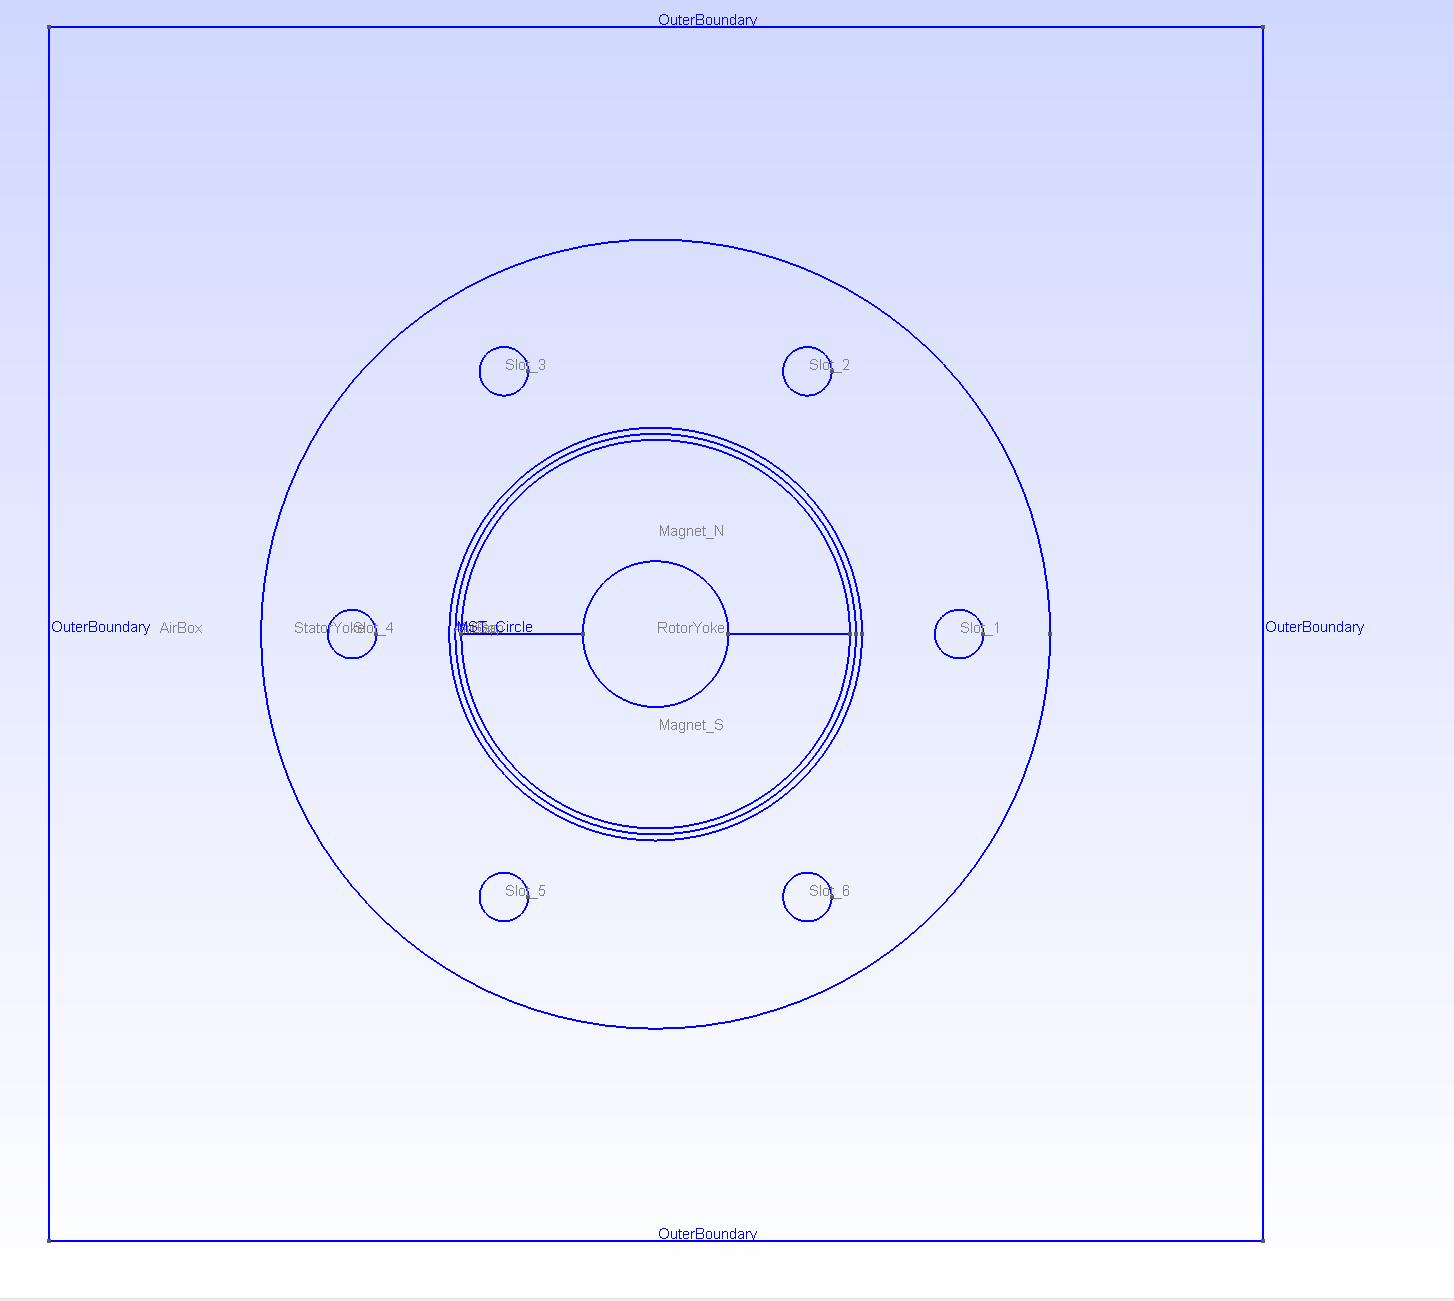

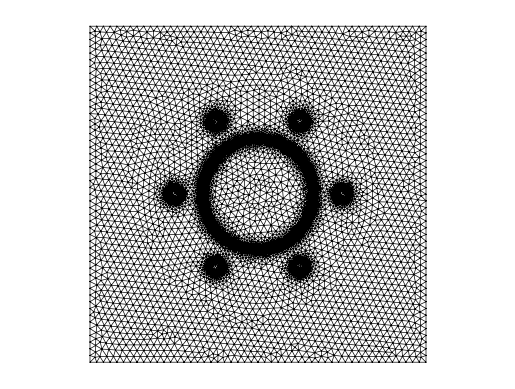

In [2]:
import meshio
from skfem import *
from skfem.helpers import dot, grad
import numpy as np

from skfem.io.meshio import from_meshio

# Add repository root to Python path. Helps to find files and modules
from pathlib import Path
import sys
sys.path.insert(0, str(Path.cwd().parent))


m = meshio.read("mesh/mesh_pmsm_2d.msh")

mesh = from_meshio(m)

from skfem.visuals.matplotlib import draw
import matplotlib.pyplot as plt

import matplotlib.tri as mtri

draw(mesh)
plt.axis("equal")
plt.show()



Define basis for each region

In [3]:
from skfem import Basis, ElementTriP2

e = ElementTriP2()
basis = Basis(mesh, e, intorder=4)

basis_rotor_yoke = basis.with_elements(mesh.subdomains["RotorYoke"])
basis_stator_yoke = basis.with_elements(mesh.subdomains["StatorYoke"])
basis_air_box = basis.with_elements(mesh.subdomains["AirBox"])
basis_air_gap = basis.with_elements(mesh.subdomains["AirGap"])

basis_magnet = basis.with_elements(mesh.subdomains["Magnet"])

from skfem import FacetBasis

# MST line intgral path. Circe in the middle of airgap
fbasis = FacetBasis(
    mesh,
    basis.elem,
    facets=mesh.boundaries["MST_Circle"],
)

# Slot to phzse current mapping
"""
Slot_1 → A+
Slot_2 → B−
Slot_3 → C+
Slot_4 → A−
Slot_5 → B+
Slot_6 → C−
"""

slot_bases = [
    basis.with_elements(mesh.subdomains[f"Slot_{i}"])
    for i in range(1, 7)
]

# For example Slot_1 → A+
print(slot_bases[0])

# Evaluate slot area for to solve the current denisty
# Test winding area
from skfem import Functional
@Functional
def area(w):
    return 1.0

print()
slot_area = area.assemble(slot_bases[0])
#slot_area = 5.0265e-5  # m^2, from Comsol
print("In units of m: ", slot_area)

<skfem CellBasis(MeshTri1, ElementTriP2) object>
  Number of elements: 248
  Number of DOFs: 38737
  Size: 214272 B

In units of m:  5.007820143519473e-05


To model the torque during steady state situation, we have to aling the rotor permanent magnet with stator field. Also we have to rotate the rotor at same frequency, than the stator currents. To get maximum torque, we want to have maximum stator current at the moment the permanent magnet is facing the slot. In this picture we have the initial condition that we are looking for. By Lorentz force theorem and right hand rule we see that this produces positive torque.

Checkout verification/max_torque_rotation.gif to see it in action!

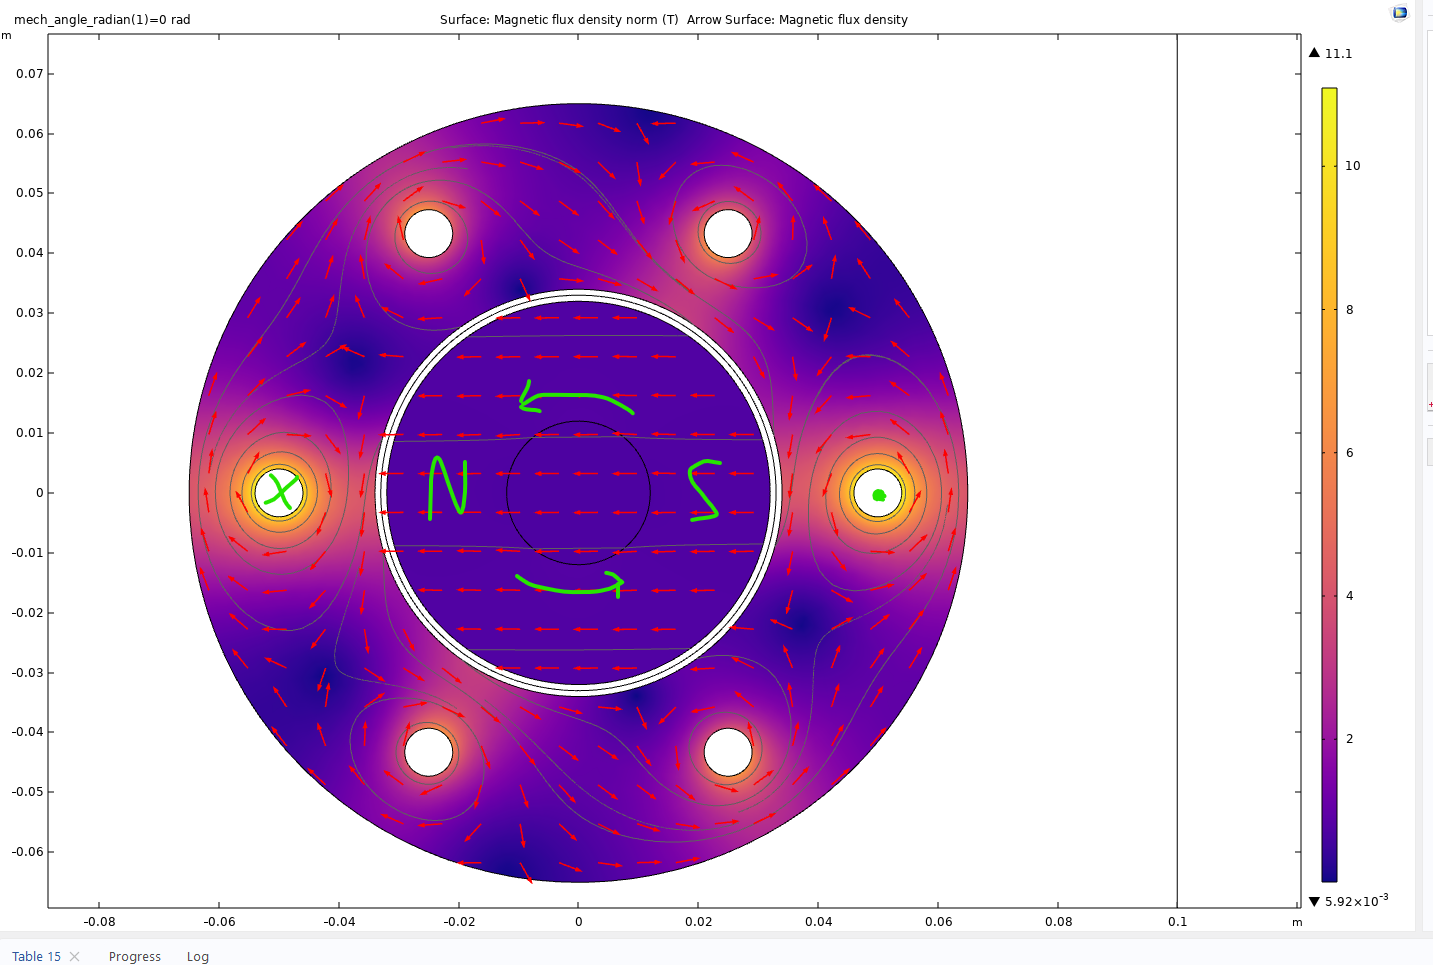

#### Conditions:
- excite +A and -A at mechnaical_angle=0 
- make remanence vector pointin [-1; 0]  (-x directionn)
- The current frequency has to be same than the mechnaical angle the rotor is rotating. A,B,C phase current have 120 degree offset, which makes it rotate. We just need to control the speed

When all of these condition are satisfied, we expect to get approximately constant torque. This happends because the relative position is same in all mechnaical angles in permanent magnets and stator field, thus the torque produced is same.

In [26]:

mu0 = 4 * np.pi * 1e-7
mu_air = mu0
mu_pm = mu0
mu_iron = 1000 * mu0
# w.mu little confusing but it just wraps the permeability to some variable w
@BilinearForm
def laplace(A, v, w):
    return 1/w.mu*dot(grad(A), grad(v))

I_0 = 2
f = 50 # Frequency of the current
omega = 2*np.pi*f
t = 0  # start time
Nturns = 100

Br = 0.8 # Remanence 
remanence_angle = np.pi # Angle of the remanence in the magnet. 0 means that the magnetization is along the  negativex-axis
torques_arkkio = []
torques_mst = []

number_of_steps = 100
mechanical_angle_step = 2 * np.pi / number_of_steps

mechanical_angles = np.linspace(
    0,
    2 * np.pi,
    number_of_steps,
    endpoint=False  # 2pi not indluded, because 0 and 2pi are the same position
)

Az_all = []

A_phase = 0
B_phase = 2*np.pi/3
C_phase = 4*np.pi/3
phase_shift = 0

iteration = 1
for mech_angle_radian in mechanical_angles:

    I_A = I_0*np.cos(mech_angle_radian + A_phase + phase_shift)
    I_B = I_0*np.cos(mech_angle_radian + B_phase + phase_shift)
    I_C = I_0*np.cos(mech_angle_radian + C_phase + phase_shift)

    J_A = Nturns * I_A / slot_area
    J_B = Nturns * I_B / slot_area
    J_C = Nturns * I_C / slot_area
    @LinearForm
    def slot_rhs(v, w):
        return w.J * v


    @LinearForm
    def magnet_rhs(v, w):
        Brx = w.Brx
        Bry = w.Bry
        mu = w.mu  

        return 1/mu * (
            Brx * v.grad[1]
            -
            Bry * v.grad[0]
        )

    # Assemble left hand side. We have linear materials, so just change permeability

    # RotorYoke and StatorYoke are modelled as magnetic iron
    S_mat = laplace.assemble(basis_rotor_yoke, mu=mu_iron)
    S_mat += laplace.assemble(basis_stator_yoke, mu=mu_iron)

    # Other parts are modelled as non magnetic
    S_mat += laplace.assemble(basis_air_box, mu=mu_air)
    S_mat += laplace.assemble(basis_air_gap, mu=mu_air)
    S_mat += laplace.assemble(basis_magnet, mu=mu_air)
    

    # Slots (non magnetic air with current density source) are modelled as non magnetic
    for basis_i in slot_bases:
        S_mat += laplace.assemble(basis_i, mu=mu_air)

    # Assemble right hand side for slots. Add current density source to each slot. We use 3phase currents
    b =  slot_rhs.assemble(slot_bases[0], J = +J_A)
    b +=  slot_rhs.assemble(slot_bases[1], J = -J_B)
    b +=  slot_rhs.assemble(slot_bases[2], J = +J_C)
    b +=  slot_rhs.assemble(slot_bases[3], J = -J_A)
    b +=  slot_rhs.assemble(slot_bases[4], J = +J_B)
    b +=  slot_rhs.assemble(slot_bases[5], J = -J_C)

    # Assemble right hand side for magnets. These are the remanence source, they behave as current sources in weak form.

    # MAGNET 
    Brx = Br * np.cos(mech_angle_radian + remanence_angle)  
    Bry = Br * np.sin(mech_angle_radian + remanence_angle)

    # Keep the direction of magnetization positive for north poles
    b += magnet_rhs.assemble(
        basis_magnet,
        Brx= Brx,
        Bry= Bry,
        mu=mu_pm,
    )


    S_mat, b = enforce(S_mat, b, D=mesh.boundary_nodes())

    A_z = solve(S_mat, b)
    Az_all.append(A_z.copy())


    import numpy as np
    from skfem import Functional

    mu0 = 4 * np.pi * 1e-7
    L_stack = 1.0        # your machine's axial stack length
    airgap_thickess = 2*1e-3 ## 2mm airgap          # inner/outer radius of the AirGap annulus
    @Functional
    def arkkio_integrand(w):
        gradA = w['A'].grad           # shape (2, nelems, nqp): [dA/dx, dA/dy]
        Bx = gradA[1]
        By = -gradA[0]
    
        x, y = w.x                    # global coordinates at quadrature points
        r = np.sqrt(x**2 + y**2)
        
        integrand = ((x*Bx + y*By)*(-y*Bx + x*By)/ r)
        return integrand

    integral = arkkio_integrand.assemble(
        basis_air_gap, A=basis_air_gap.interpolate(A_z)
    )
    torque_arkkio = (L_stack / (mu0 * (airgap_thickess))) * integral
    torques_arkkio.append(torque_arkkio)


    # Interpolate your solution onto the facets
    A_f = fbasis.interpolate(A_z)
    @Functional
    def mst_torque(w):

        gradA = w["A"].grad

        Bx = gradA[1]
        By = -gradA[0]

        x, y = w.x

        nx, ny = w.n

        B2 = Bx**2 + By**2

        Txx = (Bx*Bx - 0.5*B2)/mu0
        Txy = (Bx*By)/mu0
        Tyx = Txy
        Tyy = (By*By - 0.5*B2)/mu0

        fx = Txx*nx + Txy*ny
        fy = Tyx*nx + Tyy*ny

        return x*fy - y*fx

    torque_mst = mst_torque.assemble(
        fbasis,
        A=A_f,
    )

    torque_mst *= L_stack
    torques_mst.append(torque_mst)

    theta_elec = omega * t + phase_shift
    print("Difference of angles in rotor magnet and stator field, should be constant:", mech_angle_radian - theta_elec)
    print(f"{iteration/number_of_steps*100:.1f}% done")
    # omega = d(mechanical_angle)/dt   ->  dt = d(mechanical_angle)/omega
    # So the amount we have to update time is the mechanical angle step divided by the angular speed of the rotor
    dt = mechanical_angle_step / omega
    t = t + dt

    iteration += 1




Difference of angles in rotor magnet and stator field, should be constant: 0.0
1.0% done
Difference of angles in rotor magnet and stator field, should be constant: 0.0
2.0% done
Difference of angles in rotor magnet and stator field, should be constant: 0.0
3.0% done
Difference of angles in rotor magnet and stator field, should be constant: 0.0
4.0% done
Difference of angles in rotor magnet and stator field, should be constant: 0.0
5.0% done
Difference of angles in rotor magnet and stator field, should be constant: 0.0
6.0% done
Difference of angles in rotor magnet and stator field, should be constant: 0.0
7.0% done
Difference of angles in rotor magnet and stator field, should be constant: 0.0
8.0% done
Difference of angles in rotor magnet and stator field, should be constant: -1.1102230246251565e-16
9.0% done
Difference of angles in rotor magnet and stator field, should be constant: -1.1102230246251565e-16
10.0% done
Difference of angles in rotor magnet and stator field, should be cons

Compute torque

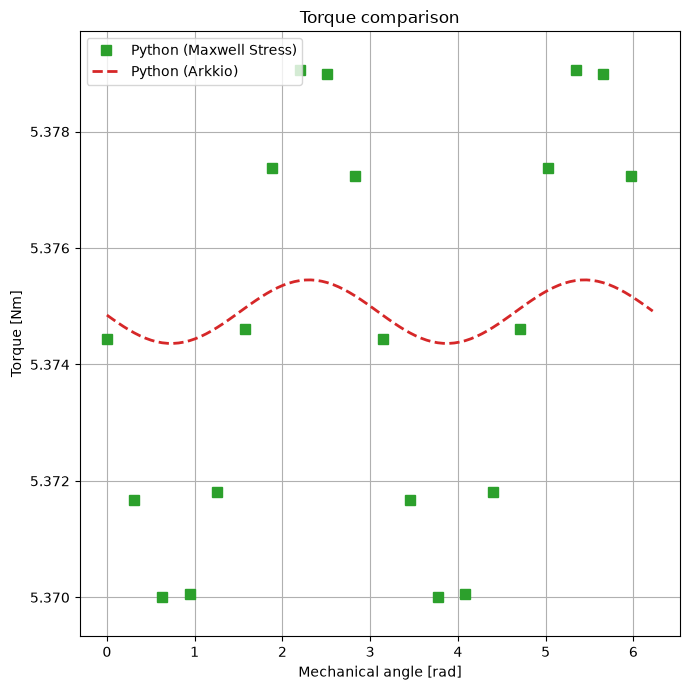

In [27]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7,7))

torques_arkkio = np.asarray(torques_arkkio)
torques_mst = np.asarray(torques_mst)
mechanical_angles = np.asarray(mechanical_angles)

# Python Maxwell Stress
ax.plot(
    mechanical_angles,
    torques_mst,
    "s",
    color="tab:green",
    linewidth=2,
    markersize=7,
    markevery=5,
    label="Python (Maxwell Stress)",
)

# Python Arkkio
ax.plot(
    mechanical_angles,
    torques_arkkio,
    "--",
    color="tab:red",
    linewidth=2,
    markersize=5,
    markevery=5,
    label="Python (Arkkio)",
)

ax.set_xlabel("Mechanical angle [rad]")
ax.set_ylabel("Torque [Nm]")
ax.set_title("Torque comparison")
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()


# Results show that torque is nearly constant. The small variations in torque are due to the discretization of the mesh and numerical errors.
# Both, Maxwell Stress and Arkkio give similar result.

### Results

In [28]:
# Load COMSOL data
data = np.loadtxt(
    "verification/comsol_torques.txt",
    comments="%"
)

angles = data[:, :0]
comsol_torque_arkkio = data[:, 1]
comsol_torque_mst = data[:, 2]


# Print results

def print_stats(name, torque):
    mean = np.mean(torque)
    std = np.std(torque)
    p2p = np.ptp(torque)              # max - min
    ripple = 100 * p2p / mean         # peak-to-peak ripple (%)

    print(f"{name}")
    print(f"  Mean torque        : {mean:8.5f} Nm")
    print(f"  Standard deviation : {std:8.6f} Nm")
    print(f"  Peak-to-peak       : {p2p:8.6f} Nm")
    print(f"  Ripple             : {ripple:8.4f} %")
    print()

print_stats("Python (Arkkio)", torques_arkkio)
print_stats("COMSOL (Arkkio)", comsol_torque_arkkio)
print_stats("COMSOL (Maxwell Stress)", comsol_torque_mst)
print_stats("Python (Maxwell Stress)", torques_mst)



Python (Arkkio)
  Mean torque        :  5.37491 Nm
  Standard deviation : 0.000386 Nm
  Peak-to-peak       : 0.001091 Nm
  Ripple             :   0.0203 %

COMSOL (Arkkio)
  Mean torque        :  5.35327 Nm
  Standard deviation : 0.023392 Nm
  Peak-to-peak       : 0.066477 Nm
  Ripple             :   1.2418 %

COMSOL (Maxwell Stress)
  Mean torque        :  5.37664 Nm
  Standard deviation : 0.010928 Nm
  Peak-to-peak       : 0.031048 Nm
  Ripple             :   0.5775 %

Python (Maxwell Stress)
  Mean torque        :  5.37452 Nm
  Standard deviation : 0.003344 Nm
  Peak-to-peak       : 0.009449 Nm
  Ripple             :   0.1758 %



Results are close to COMSOL, and the torque is non-zero and constant over one revolution.